<a href="https://colab.research.google.com/github/abdou-majeed/language-tasks/blob/main/language_identification_and_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Language Identification and Classification Using Compression-Based Distances

**Author:** Abdou
**Based on:** MSc Thesis — *Relative Entropy, Data Compression, and Applications*

This notebook implements compression-based methods for:
1. **Entropy estimation** — estimating the per-character entropy of natural language texts using gzip compression.
2. **Language identification** — recognizing which language a short text snippet belongs to, by using compression to provide a measure of distance to known training corpora.
3. **Language classification** — grouping languages into families using pairwise 'distances' and community detection on graphs.

The key insight (Benedetto et al., 2002) is that the relative entropy between two texts can be approximated by measuring how much better an optimal compressor can compress a snippet when it has access to a reference text in the same language, compared to when it has access to a reference text in a different language.

By optimal compressor, we mean a compressor that compresses a text down to its entropy asymptotically. We use gzip which implements LZ77 + Huffman because LZ77 is known to achieve this lower bound asymptotically.

## Datasets

- **Dataset A (UDHR):** The Universal Declaration of Human Rights translated into 281 languages, from [Aalto University](http://research.ics.aalto.fi/cog/data/udhr/).
- **Dataset B (Kaggle):** A collection of ~10,000 text samples in total, in 17 languages, from [Kaggle](https://www.kaggle.com/datasets/basilb2s/language-detection).
- **Dataset C (Lolita):** The opening paragraph of *Lolita* by Vladimir Nabokov, translated into 17 languages.

## References

<!-- - Benedetto, D., Caglioti, E., & Loreto, V. (2002). Language Trees and Zipping. Physical Review Letters, 88(4). https://doi.org/10.1103/physrevlett.88.048702
- Huffman, D. (1952). A Method for the Construction of Minimum-Redundancy Codes. Proceedings Of The IRE, 40(9), 1098‑1101. https://doi.org/10.1109/jrproc.1952.273898
- Vatanen, T., Väyrynen, J., & Virpioja, S. (2010, 1 mai). Language Identification of Short Text Segments with N-gram Models. ACL Anthology. https://aclanthology.org/L10-1193/
- Ziv, J., & Lempel, A. (1977). A universal algorithm for sequential data compression. IEEE Transactions On Information Theory, 23(3), 337‑343. https://doi.org/10.1109/tit.1977.1055714
 -->
- Benedetto, D., Caglioti, E. and Loreto, V. (2002) ‘Language trees and zipping’, Physical Review Letters, 88(4). doi:[10.1103/physrevlett.88.048702](https://doi.org/10.1103/PhysRevLett.88.048702).
- [Language Identification of Short Text Segments with N-gram Models](https://aclanthology.org/L10-1193/) (Vatanen et al., LREC 2010).
- [About the Universal Declaration of Human Rights Translation Project](https://www.ohchr.org/en/human-rights/universal-declaration/universal-declaration-human-rights/about-universal-declaration-human-rights-translation-project). (s. d.). The Office Of The High Commission For Human Rights (OHCHR).
<!-- - [The Office of the High Commission for Human Rights (OHCHR)](https://www.ohchr.org/en/human-rights/universal-declaration/universal-declaration-human-rights/about-universal-declaration-human-rights-translation-project). -->
- J. Ziv and A. Lempel, "A universal algorithm for sequential data compression," in IEEE Transactions on Information Theory, vol. 23, no. 3, pp. 337-343, May 1977, doi: [10.1109/TIT.1977.1055714](https://doi.org/10.1109/TIT.1977.1055714).
keywords: {Encoding;Symbols;Silicon;Codes;Decoding;Data compression;Compression algorithms;Lower bound;Feeds;Upper bound},
- D. A. Huffman, "A Method for the Construction of Minimum-Redundancy Codes," in Proceedings of the IRE, vol. 40, no. 9, pp. 1098-1101, Sept. 1952, doi: [10.1109/JRPROC.1952.273898](https://doi.org/10.1109/JRPROC.1952.273898).
keywords: {Transmitters},

In [ ]:
# Import standard library packages/modules
import os
import csv
import gzip
import random

In [ ]:
# Install third-party packages if not available
# %pip install numpy
# %pip install matplotlib
# %pip install networkx

In [ ]:
# Import third-party packages/modules
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import community

In [ ]:
# Seed for reproducibility
random.seed(42)

## Character Encoding in Python

Python strings are sequences of Unicode code points. The `len()` function returns the number of
code points, while `len(s.encode("utf-8"))` returns the number of bytes under UTF-8 encoding.
Characters from different scripts might have different byte sizes, which matters for compression-based
entropy estimation.

NB: In the following, whenever we say 'character' we mean 'unicode codepoint'. In general, the meaning of 'character' is more complicated.  

In [ ]:
# Demonstrate how different scripts use different numbers of bytes per character
sample_characters = {
    "Hindi" :  "क",
    "German":  "ß",
    "Latin" :  "a",
    "French":  "è",
}

header = f"| {'Character':^9} | {'Script':^6} | {'Unicode length':^14} | {'Size (bytes)':^12} |"
separator = f"| {'-'*9} | {'-'*6} | {'-'*14} | {'-'*12} |"
print(header)
print(separator)
for script, char in sample_characters.items():
    unicode_len = len(char)
    byte_size = len(char.encode("utf-8"))
    print(f"| {char:^9} | {script:^6} | {unicode_len:^14} | {byte_size:^12} |")

| Character | Script | Unicode length | Size (bytes) |
| --------- | ------ | -------------- | ------------ |
|     क     | Hindi  |       1        |      3       |
|     ß     | German |       1        |      2       |
|     a     | Latin  |       1        |      1       |
|     è     | French |       1        |      2       |


## Compression and Entropy Estimation

We use `gzip.compress` (which implements LZ77 + Huffman coding) to estimate the entropy
of a text. The estimated entropy in bits per character is:

$$\hat{H} = \frac{8 \times \text{byte_size(compressed)}}{\text{unicode_length(text)}}$$

where `byte_size(compressed)` is the byte length of the compressed output and `unicode_length(text)`
is the number of Unicode code points in the original text.

**Caveat:** gzip adds a fixed header of roughly 18 bytes.

In [ ]:
def compress_text(text: str) -> bytes:
    """Compress a UTF-8 encoded text using gzip (LZ77 + Huffman)."""
    return gzip.compress(text.encode("utf-8"))


def estimate_entropy(text: str) -> float:
    """Estimate the per-character entropy (bits/char) of a text via gzip compression.

    Parameters
    ----------
    text : str
        Input text (Unicode string).

    Returns
    -------
    float
        Estimated entropy in bits per character.
    """
    if not text:
        raise ValueError("Cannot estimate entropy of an empty text.")
    compressed = compress_text(text)
    return 8 * len(compressed) / len(text)

In [ ]:
# Quick test
print(estimate_entropy("Bonjour, je m'appelle John Doe."))
print(estimate_entropy("Bonjour, je m'appelle John Doe. Bonjour, je m'appelle John Doe."))
print(estimate_entropy("Bonjour, je m'appelle John Doe. Bonjour, je m'appelle John Doe. Bonjour, je m'appelle John Doe."))

13.161290322580646
6.984126984126984
4.631578947368421


## Dataset A: Universal Declaration of Human Rights (UDHR)

The UDHR corpus contains translations of the Universal Declaration of Human Rights
in 281 languages (or so the source claims), distributed as plain-text files by Tommi Jauhiainen et al.
Each translation is stored as a UTF-8 text file.

- Source: [Aalto University UDHR Corpus](http://research.ics.aalto.fi/cog/data/udhr/)
- Structure: one `.txt` file per language, named by a short language code (e.g. `eng.txt`).
- A companion file `languages.txt` maps each code to a human-readable language name.

Each text is roughly 10,000 characters long.

In [ ]:
# --- Configuration ---
UDHR_LANGUAGES_PATH = "udhr/languages.txt"
UDHR_TEXT_DIR = "udhr/txt"

## Step 1 — Read the language list

We parse `languages.txt` to build a mapping from language codes to language names.
Each line has the format `code<TAB>name`.

In [ ]:
def load_language_map(filepath: str) -> list[tuple[str, str]]:
    """Load language (code, name) pairs from the UDHR languages.txt file.

    Parameters
    ----------
    filepath : str
        Path to the tab-separated languages file.

    Returns
    -------
    list[tuple[str, str]]
        List of (language_code, language_name) tuples.
    """
    entries = []
    with open(filepath, mode="r", encoding="utf-8") as f:
        for line in f:
            code, name = (item.strip() for item in line.rstrip("\r\n").split("\t"))
            entries.append((code, name))
    return entries


language_entries = load_language_map(UDHR_LANGUAGES_PATH)
print(f"Loaded {len(language_entries)} language entries.")

Loaded 372 language entries.


In [ ]:
# Snippet of language_entries
language_entries[:5]

[('abk', 'Abkhaz'),
 ('atj', 'Achehnese'),
 ('jiv', 'Achuar Chicham'),
 ('acu', 'Achuar-Shiwiar'),
 ('aja', 'Adja')]

## Step 2 — Check for duplicate codes and names, then build a `code -> name` mapping

Before building the code-to-name dictionary, we verify that:
- No two entries share the same language code (would silently overwrite).
- No two entries share the same language name (would be ambiguous).

In [ ]:
# Check for duplicated codes
all_codes = [code for code, _ in language_entries]
if len(all_codes) != len(set(all_codes)):
    print("There are duplicated codes. Stop and handle them!")
else:
    print("No duplicated code.")

# Check for duplicated names
all_names = [name for _, name in language_entries]
if len(all_names) != len(set(all_names)):
    print("There are duplicated names. Stop and handle them!")
else:
    print("There are no duplicated names.")

No duplicated code.
There are duplicated names. Stop and handle them!


In [ ]:
# Print the duplicated names
table = {}
for code, name in language_entries:
    if name in table:
        table[name].append(code)
    else:
        table[name] = [code]

duplicated_names = {}
for name, codes in table.items():
    if len(codes) > 1:
        duplicated_names[name] = codes

for name, codes in duplicated_names.items():
    print(f"{name}:")
    for code in codes:
        print(f"{"":10} + {code}")

Latin (Latina):
           + ltn1
           + ltn


**Handling the duplicates**

These are the first characters in each of the files ``ltn.txt`` and ``ltn1.txt``. **They do appear to be different**.

Sample from ``ltn.txt``

    DECLARATIONEM HOMINIS IURIUM UNIVERSAM
    EXORDIUM Omnium humanae gentis partium perspecto et cognito consensum fidemque propriae dignitatis atque iurium, quae

Sample from ``ltn1.txt``

    UNIVERSALIS DE JURE HOMINUM DECLARATIO
    quae, decreto CCXVII A (III), a Communi Conventu probata et edicta est, Anno Domini MCMIIL, a.d.IV Idus Decembres.

**Our fix**

We shall use these names instead:

| Code | New name | Description |
| :--: | :------- | :---------- |
| `ltn`| 'Latin (Latina)' | its name is kept|
| `ltn1`| 'Latin (Latina) 1' |' 1' is appended to its name|

In [ ]:
# Fix the duplicate: rename 'ltn1' to distinguish it from 'ltn'
for i, (code, name) in enumerate(language_entries):
    if code == "ltn1":
        language_entries[i] = (code, name + " 1")

# Build the authoritative code -> name mapping
lang_code_to_name: dict[str, str] = {code: name for code, name in language_entries}
print(f"Language map: {len(lang_code_to_name)} entries.")

Language map: 372 entries.


## Step 3 — Read the UDHR text files

We read every `.txt` file in the folder `udhr/txt/`.

Each filename (without extension) is a language code.
We store the results in a temporary list for validation before building the final dictionary.

In [ ]:
def load_udhr_texts(text_dir: str) -> dict[str, str]:
    """Read all .txt files from the UDHR text directory.

    Parameters
    ----------
    text_dir : str
        Path to the directory containing one .txt file per language.

    Returns
    -------
    dict[str, str]
        Mapping from language code (extracted from the filename) to the full text content.
        eg. the file frn.txt produces the entry 'frn' -> 'DECLARATION UNIVERSELLE DES DROITS ...'
    """
    texts = {}
    for filename in os.listdir(text_dir):
        if not filename.endswith(".txt"):
            continue
        lang_code = filename[:-4]
        filepath = os.path.join(text_dir, filename)
        with open(filepath, mode="r", encoding="utf-8") as f:
            texts[lang_code] = f.read()
    return texts


udhr_texts = load_udhr_texts(UDHR_TEXT_DIR)
print(f"Loaded {len(udhr_texts)} UDHR text files.")

Loaded 281 UDHR text files.


## Step 4 — Cross-check files against the language list

We compare the set of files we read against the set of codes in `languages.txt`
to detect missing files and unexpected ones.

In [ ]:
expected_codes = set(lang_code_to_name)
loaded_codes = set(udhr_texts)

missing_languages = expected_codes - loaded_codes
unexpected_files = loaded_codes - expected_codes

print(f"{len(expected_codes):3} languages expected from languages.txt")
print(f"{len(loaded_codes):3} text files found in {UDHR_TEXT_DIR}/")
print(f"{len(missing_languages):3} expected but missing")
print(f"{len(unexpected_files):3} unexpected files (not in languages.txt)")

372 languages expected from languages.txt
281 text files found in udhr/txt/
 91 expected but missing
  0 unexpected files (not in languages.txt)


In [ ]:
# Double-check: confirm that the missing files truly do not exist on disk
for code in missing_languages:
    assert not os.path.exists(os.path.join(UDHR_TEXT_DIR, code + ".txt")),\
    f"File {code}.txt exists but was not read!\n"

In [ ]:
print(f"Missing languages: {sorted(missing_languages)}")

Missing languages: ['1121', '1122', '1123', '1124', '1125', '1126', '1127', 'aii', 'alt', 'amh', 'asm', 'azb', 'azb1', 'bfa', 'bgp', 'bhj', 'bms', 'bng', 'bvi', 'ccc', 'cjs', 'cof', 'crm', 'div', 'dzo', 'esb', 'eve', 'evn', 'gbc', 'geo', 'gjr', 'hbr', 'hnd', 'iii', 'jiv', 'kaz', 'kdo', 'khk', 'khm', 'kjh', 'kjv', 'krl', 'ksh', 'ksw', 'kur', 'kwi', 'lot', 'mjs', 'mkd', 'mqm', 'mrt', 'nav', 'nep', 'nio', 'nol', 'nus', 'ojb', 'ory', 'pbu', 'pnj1', 'prs', 'prs1', 'pwo', 'qug', 'sah', 'shk', 'sjn', 'skr', 'skt', 'snd', 'snh', 'src2', 'taj', 'tca', 'tck', 'tcv', 'tcw', 'tgn', 'thj', 'tic', 'tov', 'ttr', 'tyv', 'uig', 'urd', 'uzb1', 'vep', 'vie', 'ydd', 'ykg', 'yrk']


I checked a number of them by hand too, and indeed, the files are not present.

I will record the missing languages in the file `udhr/missing_languages.txt` for reference.

In [ ]:
# Record missing languages for reference
with open("udhr/missing_languages.txt", mode="w", encoding="utf-8") as f:
    f.write("\n".join(sorted(missing_languages)) + "\n")
print(f"Wrote {len(missing_languages)} missing language codes to 'udhr/missing_languages.txt'")

Wrote 91 missing language codes to 'udhr/missing_languages.txt'


In [ ]:
print(sorted(udhr_texts.keys()))

['1111', '1112', '1114', '1115', '1116', '1117', '1118', '1119', '1120', '1128', 'abk', 'acu', 'afk', 'agr', 'aja', 'ako', 'aln', 'amc', 'ame', 'amr', 'arl', 'arm', 'aru', 'arz', 'ass', 'atj', 'aub', 'auv1', 'aym', 'bba', 'bci', 'bcy', 'bem', 'bkl', 'blg', 'blu', 'boa', 'bpr', 'bra', 'brt', 'bsq', 'btb', 'bzc', 'cab', 'cak1', 'cbr', 'cbs', 'cbt', 'cbu', 'ccx', 'ceb', 'chj', 'chn', 'cic', 'cjd', 'cjk', 'cln', 'cni', 'coi', 'cot', 'cpp', 'cpu', 'crs', 'csa', 'czc', 'dag', 'den', 'dga', 'dinka', 'dns', 'dum', 'dut', 'dyo', 'edo', 'eml', 'eng', 'esg', 'est', 'ewe', 'fae', 'fal', 'fin', 'fji', 'foa', 'fri', 'frl', 'frn', 'frn1', 'frn2', 'fum', 'fum1', 'gac1', 'gac2', 'gag', 'gax', 'gej', 'ger', 'gkp1', 'gli1', 'gln', 'gls', 'grk', 'gua', 'guc', 'gun', 'hak', 'hat', 'hat1', 'hea', 'hil', 'hms', 'hna', 'hng', 'hni', 'huu', 'hva', 'hwi', 'ibb', 'ice', 'igr', 'ilo', 'inz', 'itn', 'jan', 'jpn', 'kas', 'kbp', 'kdb1', 'kde', 'kea', 'kkn', 'kng', 'kon', 'koo1', 'kph', 'kqn', 'kri', 'lap1', 'lat', '

In [ ]:
# What are those digits?
# Inspect some of the numeric codes
for code in sorted(udhr_texts.keys())[:20]:
    print(code, '\t', lang_code_to_name[code])

1111 	 Ñahñú (Otomí)
1112 	 Purhépecha
1114 	 Oshiwambo (Ndonga)
1115 	 Esperanto
1116 	 Q'echi/Kekchi
1117 	 K'iche' (Quiché)
1118 	 Tének (Huasteco)
1119 	 Interlingua
1120 	 Ido
1128 	 Forro
abk 	 Abkhaz
acu 	 Achuar-Shiwiar
afk 	 Afrikaans
agr 	 Aguaruna
aja 	 Adja
ako 	 Wama
aln 	 Albanian
amc 	 Amahuaca
ame 	 Amuesha-Yanesha
amr 	 Amarakaeri


In [ ]:
# Sample texts from a few languages of interest
# Spot-check a few languages
for lang_code, label in [("1118", "Tének (Huasteco)"), ("1119", "Interlingua"), ("eng", "English"), ("frn", "French"), ("arz", "Arabic"), ("foa", "Fon")]:
    if lang_code in udhr_texts:
        print(f"=== {label} ({lang_code}) ===")
        print(udhr_texts[lang_code][:200])
        print()

=== Tének (Huasteco) (1118) ===
JUNKUNAL BITSOWTSIK
Ti laju, in ajumtal a iich' laju chaab ban tamub 1948, an junkun- talaab ban junkunal bitsowtsik ulwat xi yajat ti ku chu'uw an tsubaxtalaab xi techee' ne'ech ka xalk'an. Tin ok'ne

=== Interlingua (1119) ===
DECLARATION UNIVERSAL DEL DERECTOS HUMAN
PREAMBULO Considerante que le recognoscentia del dignitate inherente a tote le membros del familia human e de lor derectos equal e inalienabile constitue le fu

=== English (eng) ===
Universal Declaration of Human Rights
Preamble Whereas recognition of the inherent dignity and of the equal and inalienable rights of all members of the human family is the foundation of freedom, just

=== French (frn) ===
Déclaration universelle des droits de l'homme
Préambule Considérant que la reconnaissance de la dignité inhérente à tous les membres de la famille humaine et de leurs droits égaux et inaliénables cons

=== Arabic (arz) ===
‫اﻹﻋﻼن اﻟﻌﺎﻟﻤﻲ ﻟﺤﻘﻮق اﻹﻧﺴﺎن )أ(‬

‫اﻟﺪﻳﺒﺎﺟﺔ‬ ‫ﻟ ّﺎ ﻛﺎن اﻻﻋﺘﺮاف ﺑﺎﻟﻜﺮا

## Step 6 — Detect duplicate declarations

Quick sanity check.

Normally, we expect the content of two files to be different.
They are written in two different languages after all.
Since each text is only ~10,000 characters long, we can afford to compare them in full.

In [ ]:
print(f"Total texts: {len(udhr_texts)}")
unique_texts = len(set(declaration for _, declaration in udhr_texts.items()))
print(f"Unique texts: {unique_texts}")
if unique_texts != len(udhr_texts):
    print("There are languages with identical content. Strange!")
else:
    print("There are no duplicates")

Total texts: 281
Unique texts: 279
There are languages with identical content. Strange!


In [ ]:
# Find the groups with identical content
temporary = {}
for lang_code, declaration in udhr_texts.items():
    if declaration in temporary:
        temporary[declaration].append(lang_code)
    else:
        temporary[declaration] = [lang_code]

duplicate_groups = {declaration: lang_codes for declaration, lang_codes in temporary.items() if len(lang_codes) > 1}
print("Groups of languages with identical udhr_texts content.")
for _, lang_codes in duplicate_groups.items():
    first = True
    for code in lang_codes:
        if first:
            print()
            print(f"\t+ {code!r}: {lang_code_to_name[code]!r}")
            first = False
        else:
            print(f"\t  {code!r}: {lang_code_to_name[code]!r}")

Groups of languages with identical udhr_texts content.

	+ 'fum1': 'Pulaar'
	  'fum': 'Peuhl'

	+ 'cpp': 'Campa pajonalino'
	  'cbs': 'Cashinahua'


In [ ]:
# Sample texts from the duplicate_groups
for lang_code, label in [('fum', 'Peuhl'), ('fum1', 'Pulaar'), ('cpp', 'Campa pajonalino'), ('cbs', 'Cashinahua')]:
    if lang_code in udhr_texts:
        print(f"=== {label} ({lang_code}) ===")
        print(udhr_texts[lang_code][:200])
        print()

=== Peuhl (fum) ===
NANONDIRAL WINNDEREYANKEEWAL HAKKEEJE AADE
NAATIRKA E tuugnaadeko wonde keftingal horma kala neɗɗo e nder ɓesngu aadee e hakkeeji potɗi woni dnaɗɗuudi ndimaague potal e jam e nder aduna, E tuugnaade w

=== Pulaar (fum1) ===
NANONDIRAL WINNDEREYANKEEWAL HAKKEEJE AADE
NAATIRKA E tuugnaadeko wonde keftingal horma kala neɗɗo e nder ɓesngu aadee e hakkeeji potɗi woni dnaɗɗuudi ndimaague potal e jam e nder aduna, E tuugnaade w

=== Campa pajonalino (cpp) ===
10 de diciembre de 1948 anu, xanen ibu ichapa ichaxun, na jancha kenenibuki. Xanen ibu tibin javen nabu jau yuinunven, na janchadan.

JAVADA JUNIBUN MAl DASIBÍ AUN AKAIBUN, JATU NEMATIDUBUMAKI
Preambu

=== Cashinahua (cbs) ===
10 de diciembre de 1948 anu, xanen ibu ichapa ichaxun, na jancha kenenibuki. Xanen ibu tibin javen nabu jau yuinunven, na janchadan.

JAVADA JUNIBUN MAl DASIBÍ AUN AKAIBUN, JATU NEMATIDUBUMAKI
Preambu



Peuhl vs. Pulaar


*   Search for the files for one written in **Fulfude** as this might shed light on the mystery.
*   Check the OHCHR website for complete information.



In [ ]:
# Looking for fulfulde. Maybe its code starts with an 'f'?
print("Language codes from 'languages.txt' starting with an 'f'. Is Fulfude present?")
for code, name in lang_code_to_name.items():
    if code[0] == 'f':
        print(code, name)

Language codes from 'languages.txt' starting with an 'f'. Is Fulfude present?
fal Chin Falam
fae Faroese
fji Fijian
fin Finnish
foa Fon
frn French (Français)
fri Frisian
frl Friulian (Friulano)
fum Peuhl
frn2 Picard
fum1 Pulaar
frn1 Walloon/Wallon


In [ ]:
# Maybe fulfulde exists under another code
print("Maybe Fulfude is under another code. Search for language names containing 'uld'")
found = False
for name in lang_code_to_name.values():
    if 'uld' in name:
        found = True
        print(name)
if not found:
    print("Done searching. Nothing found!")

Maybe Fulfude is under another code. Search for language names containing 'uld'
Done searching. Nothing found!


I am still not sure about **Peuhl** vs. **Pulaar distinction**. I found confusing answers on the internet.

Research on the OHCHR website provide very little helpful information. I now know that the Fulfude text is totally different. The declaration written in Peuhl and Pulaar are indeed identical (I checked the .pdf files) and no explanation is provided. You should check this page:
[UHCHR Peuhl_Pulaar_Fulfude](https://www.ohchr.org/en/search?f%5B0%5D=event_type_taxonomy_term_name%3AUniversal%20Declaration%20of%20Human%20Rights&f%5B1%5D=language_taxonomy_term_name%3AFulfude&f%5B2%5D=language_taxonomy_term_name%3APeuhl&f%5B3%5D=language_taxonomy_term_name%3APulaar&f%5B4%5D=language_taxonomy_term_name%3APular).

In language recognition this might lead to false negative that shouldn't be.

My decision is to keep only one of Peuhl and Pulaar.


The situation for **Campa Pajonalino** vs. **Cashinahua** is very different.

Those languages are not even in the same language family.
| Languages | Families |
| :---: | :---: |
| Campa Pajonalino | Arawak |
| Cashinahua | Pano |

It is unfortunate that I can not tell wether the text is in the claimed language to begin with.

**A possible solution**: Maybe use a language identifier that is known to have 100% accuracy on texts as long as the declaration. That will let me confirm the label.

**Result**: Google translate does not handle those languages either.

I choose to remove those two languages from the data I use, as they are not required for the task at hand. We already have 270+ languages.

**FINAL DECISION**

The languages **Pulaar**, **Campa Pajonalino**, and **Cashinahua** are removed from udhr_texts. **Peuhl** is kept.

| Code | Name | Action |
| :--- | :--- | :---: |
| `fum` | Peuhl | Kept |
| `fum1` | Pulaar | <mark>**Removed**</mark> |
| `cpp` | Campa pajonalino | <mark>**Removed**</mark> |
| `cbs` | Cashinahua | <mark>**Removed**</mark> |


In [ ]:
# Remove the three duplicate/mislabelled entries
IGNORED_LANGUAGE_CODES = ("fum1", "cpp", "cbs")
for lang_code in IGNORED_LANGUAGE_CODES:
    del udhr_texts[lang_code]

# Record which languages were removed
with open("udhr/ignored_languages.txt", mode="w", encoding="utf-8") as f:
    f.write("\n".join(IGNORED_LANGUAGE_CODES) + "\n")

print(f"Removed {len(IGNORED_LANGUAGE_CODES)} entries.")
print(f"Remaining UDHR texts: {len(udhr_texts)}")

Removed 3 entries.
Remaining UDHR texts: 278


## Step 7 — Summary of all UDHR texts

The table below lists every language in the cleaned UDHR dictionary,
with its Unicode length (number of code points) and byte size (UTF-8).

In [ ]:
# Show only first N_sample
N_sample = 20
print(f"| {'Language':48} | {'Code':<4} | {'Distinct chars':>14} | {'Characters':>10} | {'Bytes (UTF-8)':>13} |")
print(f"| {'-'*48} | {'-'*4} | {'-'*14} | {'-'*10} | {'-'*13} |")
for lang_code in sorted(udhr_texts)[:N_sample]:
    text = udhr_texts[lang_code]
    name = lang_code_to_name[lang_code]
    distinct_chars = len(set(text))
    n_chars = len(text)
    n_bytes = len(text.encode("utf-8"))
    print(f"| {name:48} | {lang_code:<4} | {distinct_chars:>14} | {n_chars:>10} | {n_bytes:>13} |")

| Language                                         | Code | Distinct chars | Characters | Bytes (UTF-8) |
| ------------------------------------------------ | ---- | -------------- | ---------- | ------------- |
| Ñahñú (Otomí)                                    | 1111 |             70 |       8116 |          8255 |
| Purhépecha                                       | 1112 |             64 |      12131 |         12363 |
| Oshiwambo (Ndonga)                               | 1114 |             58 |      10200 |         10200 |
| Esperanto                                        | 1115 |             63 |      10125 |         10316 |
| Q'echi/Kekchi                                    | 1116 |             63 |      10233 |         10233 |
| K'iche' (Quiché)                                 | 1117 |             66 |      13635 |         13635 |
| Tének (Huasteco)                                 | 1118 |             59 |       9691 |          9720 |
| Interlingua                                 

## Dataset B: Kaggle Language Detection

A collection of ~10,000 text samples in total, across 17 languages, used for training and testing
the language identification algorithm.

Source: [Kaggle — Language Detection](https://www.kaggle.com/datasets/basilb2s/language-detection)


In [ ]:
# --- Configuration ---
KAGGLE_CSV_PATH = "kaggle.csv"

In [ ]:
def load_kaggle_dataset(filepath: str) -> dict[str, list[str]]:
    """Load the Kaggle language detection CSV into a dict of language -> text samples.

    Parameters
    ----------
    filepath : str
        Path to the CSV file with columns: Text, Language.

    Returns
    -------
    dict[str, list[str]]
        Mapping from language name to list of text samples.
    """
    texts_by_language: dict[str, list[str]] = {}
    with open(filepath, encoding="utf-8") as f:
        reader = csv.reader(f)
        header = next(reader)  # skip header
        for row in reader:
            text, language = row[0], row[1]
            if language in texts_by_language:
                texts_by_language[language].append(text)
            else:
                texts_by_language[language] = [text]
    return texts_by_language

kaggle_texts = load_kaggle_dataset(KAGGLE_CSV_PATH)
kaggle_languages = sorted(kaggle_texts)
print(f"Loaded {sum(len(v) for _, v in kaggle_texts.items())} samples across {len(kaggle_languages)} languages:")
print(kaggle_languages)

Loaded 10337 samples across 17 languages:
['Arabic', 'Danish', 'Dutch', 'English', 'French', 'German', 'Greek', 'Hindi', 'Italian', 'Kannada', 'Malayalam', 'Portugeese', 'Russian', 'Spanish', 'Sweedish', 'Tamil', 'Turkish']


In [ ]:
print(f"| {'Languages':<10} | {'Samples':>7} | {'Distinct chars':>14} | {'Total chars':>11} | {'Total bytes':>11} |")
print(f"| {'-'*10} | {'-'*7} | {'-'*14} | {'-'*11} | {'-'*11} |")
for language in sorted(kaggle_texts):
    samples = kaggle_texts[language]
    corpus = "".join(samples)
    distinct_chars = len(set(corpus))
    total_chars = len(corpus)
    total_bytes = len(corpus.encode("utf-8"))
    print(f"| {language:<10} | {len(samples):>7} | {distinct_chars:>14} | {total_chars:>11} | {total_bytes:>11} |")

| Languages  | Samples | Distinct chars | Total chars | Total bytes |
| ---------- | ------- | -------------- | ----------- | ----------- |
| Arabic     |     536 |            120 |       53167 |       94884 |
| Danish     |     428 |             81 |       39056 |       39967 |
| Dutch      |     546 |             87 |       54198 |       54314 |
| English    |    1385 |            112 |      189608 |      189764 |
| French     |    1014 |            119 |      147167 |      152509 |
| German     |     470 |             73 |       35110 |       35608 |
| Greek      |     365 |            121 |       38785 |       70126 |
| Hindi      |      63 |            161 |       76179 |      190878 |
| Italian    |     698 |            108 |       99226 |       99972 |
| Kannada    |     369 |             91 |       32360 |       88316 |
| Malayalam  |     594 |            139 |       59243 |      162921 |
| Portugeese |     739 |            103 |      102914 |      106436 |
| Russian    |     6

## Entropy Estimation

We investigate how the estimated entropy converges as a function of the text length.
For each language in the Kaggle dataset, we draw random substrings of increasing length,
compress them, and plot the resulting entropy estimate.


In [ ]:
def estimate_entropy_vs_length(
    samples: list[str],
    start: int = 1000,
    step: int = 5000,
    max_length: int | None = None,
    n_samples: int = 10,
) -> tuple[np.ndarray, np.ndarray]:
    """Estimate entropy as a function of sample length by random sampling.

    For each target length, draw `n_samples` random substrings of that length from the corpus,
    compute the entropy of each, and return the mean.

    Parameters
    ----------
    samples : list[str]
        The samples of some particular language.
    start : int
        Minimum substring length.
    step : int
        Step size between successive lengths.
    max_length : int or None
        Maximum substring length (defaults to the total length of all samples, space-joined).
    n_samples : int
        Number of random substrings to average over at each length.

    Returns
    -------
    lengths : np.ndarray
        Array of substring lengths tested.
    mean_entropies : np.ndarray
        Mean estimated entropy at each length.
    """

    if max_length is None:
        max_length = len(" ".join(samples))
    max_length = min(max_length, len(" ".join(samples)))

    lengths = np.arange(start, max_length, step)
    mean_entropies = np.empty(len(lengths))
    local_samples = samples.copy()  # Use a local copy because we will shuffle it in-place

    for idx, size in enumerate(lengths):
        entropies = []
        for _ in range(n_samples):
            random.shuffle(local_samples)
            corpus = " ".join(local_samples)
            offset = random.randint(0, len(corpus) - size)
            substring = corpus[offset : offset + size]
            entropies.append(estimate_entropy(substring))
        mean_entropies[idx] = np.mean(entropies)

    return lengths, mean_entropies

In [ ]:
# Compute entropy convergence curves for all 17 languages in the Kaggle dataset (may take a minute or two)
# MAX_CHARS = 50_000
MAX_CHARS = 200_000  # English is the language with longest corpus: ~190_000
entropy_curves: dict[str, tuple[np.ndarray, np.ndarray]] = {}

for language in kaggle_languages:
    samples = kaggle_texts[language]
    corpus = " ".join(kaggle_texts[language])
    cap = min(MAX_CHARS, len(corpus))
    lengths, entropies = estimate_entropy_vs_length(samples, max_length=cap)
    entropy_curves[language] = (lengths, entropies)
    print(f"Computed entropy curve for {language}.")

print("========================================")
print(f"Computed entropy curves for {len(entropy_curves)} languages.")

Computed entropy curve for Arabic.
Computed entropy curve for Danish.
Computed entropy curve for Dutch.
Computed entropy curve for English.
Computed entropy curve for French.
Computed entropy curve for German.
Computed entropy curve for Greek.
Computed entropy curve for Hindi.
Computed entropy curve for Italian.
Computed entropy curve for Kannada.
Computed entropy curve for Malayalam.
Computed entropy curve for Portugeese.
Computed entropy curve for Russian.
Computed entropy curve for Spanish.
Computed entropy curve for Sweedish.
Computed entropy curve for Tamil.
Computed entropy curve for Turkish.
Computed entropy curves for 17 languages.


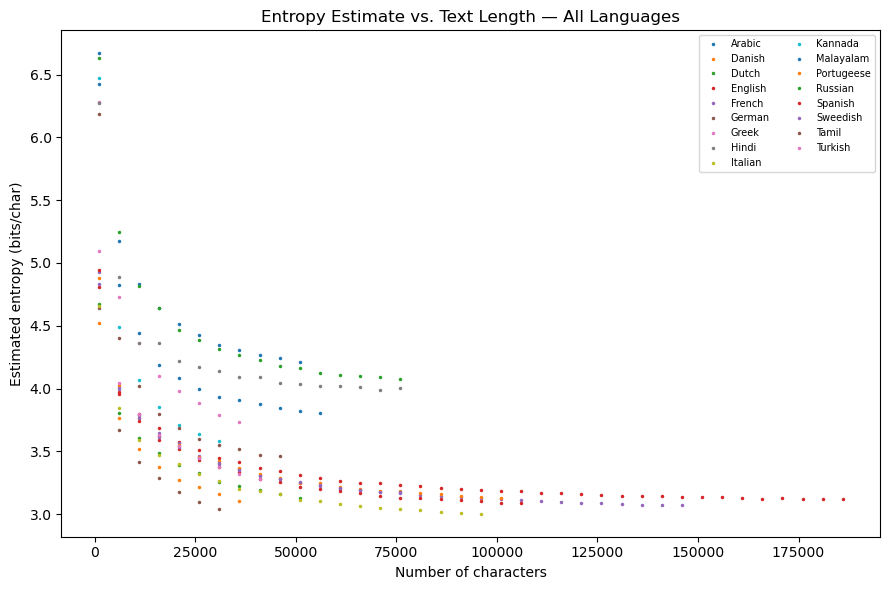

In [ ]:
plt.figure(figsize=(9, 6))
for language, (lengths, entropies) in entropy_curves.items():
    plt.plot(lengths, entropies, ".", markersize=3, label=language)
#     plt.plot(lengths, entropies, markersize=3, label=language)
plt.xlabel("Number of characters")
plt.ylabel("Estimated entropy (bits/char)")
plt.title("Entropy Estimate vs. Text Length — All Languages")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

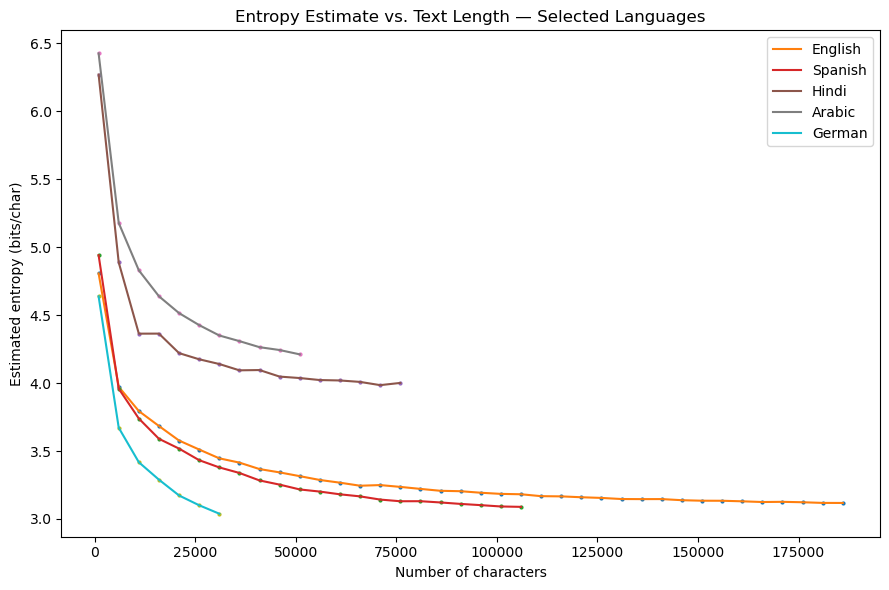

In [ ]:
plt.figure(figsize=(9, 6))
selected = ("English", "Spanish", "Hindi", "Arabic", "German")
for language in selected:
    lengths, entropies = entropy_curves[language]
    plt.plot(lengths, entropies, ".", markersize=4)
    plt.plot(lengths, entropies, markersize=4, label=language)
plt.xlabel("Number of characters")
plt.ylabel("Estimated entropy (bits/char)")
plt.title("Entropy Estimate vs. Text Length — Selected Languages")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(f"| {'Languages':<10} | {'Entropy in bits/char':^20} |")
print(f"| {'':10} | {'(best estimate)':^20} |")
print(f"| {'-'*10} | {'-'*20} |")
for language, (lengths, entropies) in sorted(entropy_curves.items()):
    best_estimate = entropies[-1]  # longest substring gives best estimate
    print(f"| {language:<10} | {best_estimate:<20.2f} |")

| Languages  | Entropy in bits/char |
|            |   (best estimate)    |
| ---------- | -------------------- |
| Arabic     | 4.21                 |
| Danish     | 3.11                 |
| Dutch      | 3.13                 |
| English    | 3.12                 |
| French     | 3.07                 |
| German     | 3.04                 |
| Greek      | 3.73                 |
| Hindi      | 4.00                 |
| Italian    | 3.00                 |
| Kannada    | 3.58                 |
| Malayalam  | 3.81                 |
| Portugeese | 3.13                 |
| Russian    | 4.08                 |
| Spanish    | 3.09                 |
| Sweedish   | 3.18                 |
| Tamil      | 3.46                 |
| Turkish    | 3.28                 |


Estimate the entropy of the same 17 languages, using the UDHR dataset.

In [ ]:
# Find the codes of those 17 languages in the UDHR language codes
SELECTED_UDHR_CODES = []
print(f"| {'The 17 languages':16} | {'UDHR Language':25} | {'UDHR code':9}")
print(f"| {'-'*16} | {'-'*25} | {'-'*9} |")

for language in kaggle_languages:
    found = False
    for lang_code, lang_name in lang_code_to_name.items():
        if language.lower() in lang_name.lower():
            found = True
            SELECTED_UDHR_CODES.append(lang_code)
            print(f"| {language:16} | {lang_name:25} | {lang_code:9} |")
    if not found:
        print(f"\033[31m| {language:16} | {'NOT FOUND':25} | {'N/A':9} |\033[0m")

| The 17 languages | UDHR Language             | UDHR code
| ---------------- | ------------------------- | --------- |
| Arabic           | Arabic (Alarabia)         | arz       |
| Arabic           | Mozarabic (Ajami)         | moz       |
| Danish           | Danish (Dansk)            | dns       |
| Dutch            | Dutch (Nederlands)        | dut       |
| English          | English                   | eng       |
| English          | Nigerian Pidgin English   | pcm       |
| French           | French (Français)         | frn       |
| French           | Seselwa Creole French     | crs       |
| German           | Deutsch (German)          | ger       |
| Greek            | Ellinika' (Greek)         | grk       |
| Hindi            | Hindi                     | hnd       |
| Italian          | Italian                   | itn       |
| Kannada          | Kannada                   | kjv       |
| Malayalam        | Malayalam                 | mjs       |
| Portugeese       | NOT F

In [ ]:
# For Arabic,  use arz & drop moz
# For English, use eng & drop pcm
# For French,  use frn & drop crs
for code in ('moz', 'pcm', 'crs'):
    SELECTED_UDHR_CODES.remove(code)

In [ ]:
# Find Portugeese and sweedish
for code, name in lang_code_to_name.items():
    if code[:2] in ('po', 'sw'):
        print(code, name)

por Portuguese
swz1 Siswati
swa Swahili/Kiswahili
swd Swedish (Svenska)


In [ ]:
# The Kaggle dataset misspells these language names:
#   'Portuguese' as 'Portugeese'
#   'Swedish' as 'Sweedish'
# We use the dataset's original labels throughout.
SELECTED_UDHR_CODES += ['por', 'swd']

In [ ]:
assert len(SELECTED_UDHR_CODES) == 17, "Something went wrong! There should be 17 languages."
for code, name in lang_code_to_name.items():
    if code in SELECTED_UDHR_CODES:
        print(f"{code} {name}")

arz Arabic (Alarabia)
dns Danish (Dansk)
ger Deutsch (German)
dut Dutch (Nederlands)
grk Ellinika' (Greek)
eng English
spn Español (Spanish)
frn French (Français)
hnd Hindi
itn Italian
kjv Kannada
mjs Malayalam
por Portuguese
rus Russian (Russky)
swd Swedish (Svenska)
tcv Tamil
trk Turkish (Türkçe)


In [ ]:
# Now, remove those that are not present in udhr_texts
print("These languages are not in udhr_texts:")
not_found = []
for code in SELECTED_UDHR_CODES:
    if code not in udhr_texts:
        not_found.append(code)
        print(f"{code} {lang_code_to_name[code]}")

SELECTED_UDHR_CODES = [code for code in SELECTED_UDHR_CODES if code not in not_found]

These languages are not in udhr_texts:
hnd Hindi
kjv Kannada
mjs Malayalam
tcv Tamil


In [ ]:
# Estimate the entropy of the remaining 13 languages with the UDHR dataset
print(f"| {'Languages':<18} | {'Code':4} | {'Entropy estimate (bits/char)':^28} |")
print(f"| {'-'*18} | {'-'*4} | {'-'*28} |")
#     print(f"| {language:<10} | {best_estimate:<20.2f} |")



# print(f"{'Language':30} {'Code':6} {'Entropy (bits/char)':>20}")
# print(f"{'-'*30} {'-'*6} {'-'*20}")
for lang_code in SELECTED_UDHR_CODES:
    if lang_code in udhr_texts:
        text = udhr_texts[lang_code]
        entropy = estimate_entropy(text)
        name = lang_code_to_name.get(lang_code, "Unknown")
        print(f"| {name:<18} | {lang_code:4} | {entropy:^28.2f} |")

| Languages          | Code | Entropy estimate (bits/char) |
| ------------------ | ---- | ---------------------------- |
| Arabic (Alarabia)  | arz  |             5.17             |
| Danish (Dansk)     | dns  |             3.01             |
| Dutch (Nederlands) | dut  |             2.78             |
| English            | eng  |             2.85             |
| French (Français)  | frn  |             3.00             |
| Deutsch (German)   | ger  |             2.98             |
| Ellinika' (Greek)  | grk  |             3.74             |
| Italian            | itn  |             2.87             |
| Russian (Russky)   | rus  |             3.65             |
| Español (Spanish)  | spn  |             2.88             |
| Turkish (Türkçe)   | trk  |             3.29             |
| Portuguese         | por  |             3.04             |
| Swedish (Svenska)  | swd  |             2.99             |


In [ ]:
# To do: compare with kaggle's estimate?

## Language Identification

How can we tell which language a short piece of text is written in, without knowing anything about the text in advance?

The idea is simple. Suppose we have a collection of long reference texts, one for each candidate language. We take our mystery snippet and append it to each reference text in turn, then compress the result. If the snippet is in the same language as the reference, the compressor will find many shared patterns between the snippet and the reference, so the compressed size will barely increase. If the snippet is in a *different* language, the compressor will find few shared patterns, and the compressed size will increase more.

Concretely, for each candidate language $L$ with training text $A_L$, we compute:

$$\Delta_L = |\text{compress}(A_L + b)| - |\text{compress}(A_L)|$$

where $b$ is the snippet and $|\cdot|$ denotes the size in bytes. The predicted language is the one with the smallest $\Delta_L$, because that is the language whose reference text the compressor could best exploit to compress the snippet.

In [ ]:
TRAIN_SIZE = 30_000
TEST_SIZE = 2_000


def split_kaggle_corpus(
    texts_by_language: dict[str, list[str]],
    train_size: int = TRAIN_SIZE,
    test_size: int = TEST_SIZE,
) -> tuple[dict[str, str], dict[str, str]]:
    """Split the Kaggle dataset into training and test corpora.

    Each language's samples are concatenated into a single string, then split
    into a training portion (first `train_size` characters) and a test portion
    (next `test_size` characters).

    Parameters
    ----------
    texts_by_language : dict[str, list[str]]
        Raw Kaggle data: language name -> list of text samples.
    train_size : int
        Number of characters for the training corpus per language.
    test_size : int
        Number of characters for the test corpus per language.

    Returns
    -------
    train_corpora : dict[str, str]
        Training text per language.
    test_corpora : dict[str, str]
        Test text per language.
    """
    train_corpora = {}
    test_corpora = {}
    for language, samples in texts_by_language.items():
        random.shuffle(samples)
        full_text = " ".join(samples)
        train_corpora[language] = full_text[:train_size]
        test_corpora[language] = full_text[train_size : train_size + test_size]
    return train_corpora, test_corpora


train_corpora, test_corpora = split_kaggle_corpus(kaggle_texts)
print(f"Train corpus sizes: {', '.join(f'{lang}: {len(t)}' for lang, t in sorted(train_corpora.items()))}")

Train corpus sizes: Arabic: 30000, Danish: 30000, Dutch: 30000, English: 30000, French: 30000, German: 30000, Greek: 30000, Hindi: 30000, Italian: 30000, Kannada: 30000, Malayalam: 30000, Portugeese: 30000, Russian: 30000, Spanish: 30000, Sweedish: 30000, Tamil: 30000, Turkish: 30000


In [ ]:
def identify_language(train_corpora: dict[str, str], snippet: str) -> str:
    """Identify the language of a text snippet using compression distance.

    For each candidate language, we measure how much the compressed size increases
    when the snippet is appended to the training corpus. The language with the
    smallest increase is the best match.

    Parameters
    ----------
    train_corpora : dict[str, str]
        Training text per candidate language.
    snippet : str
        The text snippet to classify.

    Returns
    -------
    str
        The predicted language name.
    """
    compression_deltas = {}
    for language, training_text in train_corpora.items():
        compressed_train = len(compress_text(training_text))
        compressed_combined = len(compress_text(training_text + snippet))
        compression_deltas[language] = compressed_combined - compressed_train
    return min(compression_deltas, key=compression_deltas.get)

# To do: There is no reason to compress the training_text every single time we want to classify a language

In [ ]:
# Quick test: identify a Danish snippet
sample_snippet = test_corpora["Danish"][20:50]
predicted = identify_language(train_corpora, sample_snippet)
print(f"Snippet: {sample_snippet!r}")
print(f"Predicted language: {predicted}")


Snippet: 'er koblet til Internettet kan '
Predicted language: Danish


In [ ]:
def evaluate_language_identification(
    train_corpora: dict[str, str],
    test_corpora: dict[str, str],
    snippet_length: int,
    n_samples: int = 10,
) -> dict[str, dict[str, int]]:
    """Evaluate language identification accuracy.

    For each language, draw `n_samples` random snippets of `snippet_length` characters each
    from the test corpus and classify them. Returns a confusion matrix as a nested dict.

    Parameters
    ----------
    train_corpora : dict[str, str]
        Training text per language.
    test_corpora : dict[str, str]
        Test text per language.
    snippet_length : int
        Length of each test snippet (in characters).
    n_samples : int
        Number of random snippets to test per language.

    Returns
    -------
    dict[str, dict[str, int]]
        Confusion matrix: true_language -> {predicted_language -> count}.
    """
    confusion = {}
    for true_language, test_text in test_corpora.items():
        confusion[true_language] = {}
        for _ in range(n_samples):
            offset = random.randint(0, len(test_text) - snippet_length)
            snippet = test_text[offset : offset + snippet_length]
            predicted = identify_language(train_corpora, snippet)
            if predicted in confusion[true_language]:
                confusion[true_language][predicted] += 1
            else:
                confusion[true_language][predicted] = 1
    return confusion


def print_identification_results(confusion: dict[str, dict[str, int]]) -> None:
    """Print language identification results with accuracy summary.

    Parameters
    ----------
    confusion : dict[str, dict[str, int]]
        Confusion matrix from evaluate_language_identification().
    """
    total_correct = 0
    total_samples = 0
    errors = []

    for true_language, predictions in sorted(confusion.items()):
        n_total = sum(predictions.values())
        n_correct = predictions.get(true_language, 0)
        total_correct += n_correct
        total_samples += n_total

        if n_correct == n_total:
            print(f"{true_language:12} — {n_correct}/{n_total} correct")
        else:
            wrong = {lang: count for lang, count in predictions.items() if lang != true_language}
            print(f"{true_language:12} — {n_correct}/{n_total} correct  (errors: {wrong})")
            errors.append((true_language, wrong))

    accuracy = total_correct / total_samples if total_samples > 0 else 0
    print(f"\nOverall accuracy: {total_correct}/{total_samples} = {accuracy:.1%}")
    if errors:
        print(f"Misclassifications: {len(errors)} language(s) had errors.")

In [ ]:
for snippet_length in [20, 30, 50, 70]:
    print(f"\n{'='*60}")
    print(f"Snippet length: {snippet_length} characters")
    print(f"{'='*60}")
    confusion = evaluate_language_identification(train_corpora, test_corpora, snippet_length)
    print_identification_results(confusion)


Snippet length: 20 characters
Arabic       — 10/10 correct
Danish       — 10/10 correct
Dutch        — 10/10 correct
English      — 8/10 correct  (errors: {'Italian': 1, 'Sweedish': 1})
French       — 10/10 correct
German       — 9/10 correct  (errors: {'Dutch': 1})
Greek        — 10/10 correct
Hindi        — 10/10 correct
Italian      — 8/10 correct  (errors: {'French': 2})
Kannada      — 10/10 correct
Malayalam    — 9/10 correct  (errors: {'English': 1})
Portugeese   — 9/10 correct  (errors: {'Spanish': 1})
Russian      — 10/10 correct
Spanish      — 6/10 correct  (errors: {'Portugeese': 2, 'Italian': 1, 'French': 1})
Sweedish     — 9/10 correct  (errors: {'Danish': 1})
Tamil        — 10/10 correct
Turkish      — 10/10 correct

Overall accuracy: 158/170 = 92.9%
Misclassifications: 7 language(s) had errors.

Snippet length: 30 characters
Arabic       — 10/10 correct
Danish       — 8/10 correct  (errors: {'English': 2})
Dutch        — 8/10 correct  (errors: {'English': 2})
English    

## Language Classification Using Graph Community Detection

We build a graph where each node is a language and edges connect languages whose texts
are "close" in compression distance. We then use community detection to discover
language families.

### Compression-Based Relative Distance

For two languages $\mathbb{A}$ and $\mathbb{B}$ with texts $A, B$ and held-out snippets $a, b$, the
relative distance is:

$$D(A, B) = \frac{\Delta_{Ab} - \Delta_{Bb}}{\Delta_{Bb}} + \frac{\Delta_{Ba} - \Delta_{Aa}}{\Delta_{Aa}}$$

where $\Delta_{Xy} = |\text{compress}(X + y)| - |\text{compress}(X)|$ is the compression
cost of appending snippet $y$ to text $X$. ($|\cdot|$ is the byte_length).

If $A$ and $B$ are in the same language family, their snippets compress well against each
other's training text, making $D$ small. Unrelated languages yield large $D$.

**Note on the formula:** The MSc thesis (equation 4.4.1) writes a minus sign between the two terms. This is a typo. The correct formula, as given by Benedetto et al. (2002, equation 2), uses a plus sign, which produces a symmetric, non-negative distance. The implementation below follows the original paper.

In [ ]:
def compute_relative_distance(
    text_a: str, snippet_a: str, text_b: str, snippet_b: str
) -> float:
    """Compute the compression-based relative distance between two texts.

    Parameters
    ----------
    text_a : str
        Training text for language A.
    snippet_a : str
        Held-out snippet from language A.
    text_b : str
        Training text for language B.
    snippet_b : str
        Held-out snippet from language B.

    Returns
    -------
    float
        Relative distance (lower = more similar).
    """
    compressed_a = len(compress_text(text_a))
    compressed_a_plus_a = len(compress_text(text_a + snippet_a))
    compressed_a_plus_b = len(compress_text(text_a + snippet_b))

    compressed_b = len(compress_text(text_b))
    compressed_b_plus_a = len(compress_text(text_b + snippet_a))
    compressed_b_plus_b = len(compress_text(text_b + snippet_b))

    delta_aa = compressed_a_plus_a - compressed_a
    delta_ab = compressed_a_plus_b - compressed_a
    delta_ba = compressed_b_plus_a - compressed_b
    delta_bb = compressed_b_plus_b - compressed_b

    return (delta_ab - delta_bb) / delta_bb + (delta_ba - delta_aa) / delta_aa

In [ ]:
def compute_pairwise_distances(
    texts: dict[str, str],
    lang_codes: list[str],
    snippet_size: int = 1000,
    snippet_offset: int = -1200,
) -> dict[str, dict[str, float]]:
    """Compute pairwise compression distances for a set of languages.

    Each text is split into a training portion and a held-out snippet. The snippet
    is taken from near the end of the text (at `snippet_offset`).

    Parameters
    ----------
    texts : dict[str, str]
        Mapping from language code to full text.
    lang_codes : list[str]
        Subset of language codes to compare.
    snippet_size : int
        Length of the held-out snippet (in characters).
    snippet_offset : int
        Starting position of the snippet (negative = from end).

    Returns
    -------
    dict[str, dict[str, float]]
        Upper-triangular distance matrix: distances[code_i][code_j] for i < j.
    """
    distances: dict[str, dict[str, float]] = {}

    for i in range(len(lang_codes)):
        code_a = lang_codes[i]
        full_a = texts[code_a]
        text_a = full_a[:snippet_offset]
        snippet_a = full_a[snippet_offset : snippet_offset + snippet_size]
        if len(full_a) <= abs(snippet_offset):
            raise ValueError(f"Text for {code_a!r} is too short ({len(full_a)} chars) for snippet_offset={snippet_offset}")
        distances[code_a] = {}

        for j in range(i + 1, len(lang_codes)):
            code_b = lang_codes[j]
            full_b = texts[code_b]
            text_b = full_b[:snippet_offset]
            snippet_b = full_b[snippet_offset : snippet_offset + snippet_size]

            distances[code_a][code_b] = compute_relative_distance(
                text_a, snippet_a, text_b, snippet_b
            )

    return distances

In [ ]:
def build_language_graph_and_find_communities(
    distances: dict[str, dict[str, float]],
    threshold: float,
    lang_code_to_node: dict[str, int],
) -> tuple[nx.Graph, list[set[int]]]:
    """Build a graph connecting similar languages and detect communities.

    Two languages are connected by an edge if their distance is below the threshold.
    Community detection uses the Louvain algorithm via NetworkX.

    Parameters
    ----------
    distances : dict[str, dict[str, float]]
        Upper-triangular pairwise distance matrix.
    threshold : float
        Maximum distance to create an edge.
    lang_code_to_node : dict[str, int]
        Mapping from language code to integer node ID.

    Returns
    -------
    graph : nx.Graph
        The constructed language similarity graph.
    communities : list[set[int]]
        Detected communities as sets of node IDs.
    """
    edges = []
    for code_a, neighbors in distances.items():
        for code_b, distance in neighbors.items():
            if distance < threshold:
                node_a = lang_code_to_node[code_a]
                node_b = lang_code_to_node[code_b]
                if (node_b, node_a) not in edges:
                    edges.append((node_a, node_b))

    graph = nx.Graph()
    graph.add_nodes_from(lang_code_to_node.values())
    graph.add_edges_from(edges)

    communities = sorted(
        community.louvain_communities(graph),
        key=len,
        reverse=True,
    )

    print(f"Graph: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")
    print(f"Communities found: {len(communities)}")

    # Draw the graph
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(graph, seed=42)
    node_to_code = {v: k for k, v in lang_code_to_node.items()}

    # Color nodes by community
    color_map = {}
    for idx, comm in enumerate(communities):
        for node in comm:
            color_map[node] = idx
    colors = [color_map.get(n, 0) for n in graph.nodes()]

    nx.draw(
        graph, pos,
        node_size=30,
        node_color=colors,
        cmap=plt.cm.tab20,
        edge_color="gray",
        alpha=0.7,
        width=0.5,
    )
    plt.title(f"Language Similarity Graph (threshold={threshold})")
    plt.tight_layout()
    plt.show()

    return graph, communities

In [ ]:
def print_communities(
    communities: list[set[int]],
    node_to_lang_code: dict[int, str],
    lang_code_to_name: dict[str, str],
) -> None:
    """Print detected communities with language names.

    Parameters
    ----------
    communities : list[set[int]]
        Communities as sets of node IDs.
    node_to_lang_code : dict[int, str]
        Mapping from node ID to language code.
    lang_code_to_name : dict[str, str]
        Mapping from language code to human-readable name.
    """
    for i, comm in enumerate(communities, start=1):
        print(f"\nCommunity {i} ({len(comm)} languages):")
        for node in sorted(comm):
            code = node_to_lang_code[node]
            name = lang_code_to_name.get(code, "Unknown")
            print(f"  {code:6} {name}")

### Classifying All UDHR Languages

We compute pairwise compression distances across all remaining UDHR texts (~278 languages),
build a similarity graph, and detect communities. This takes approximately 2 minutes.

**Note:** The MSc thesis used the Girvan-Newman algorithm (edge-betweenness-based) for community detection. This notebook uses the Louvain algorithm instead, which is faster and better suited for graphs of this size.

In [ ]:
def build_node_mappings(lang_codes: list[str]) -> tuple[dict[int, str], dict[str, int]]:
    """Build bidirectional mappings between language codes and integer node IDs.

    Parameters
    ----------
    lang_codes : list[str]
        Language codes to map.

    Returns
    -------
    node_to_lang_code : dict[int, str]
        Mapping from node ID (starting at 1) to language code.
    lang_code_to_node : dict[str, int]
        Mapping from language code to node ID.
    """
    node_to_lang_code = {i + 1: code for i, code in enumerate(lang_codes)}
    lang_code_to_node = {code: i + 1 for i, code in enumerate(lang_codes)}
    return node_to_lang_code, lang_code_to_node

In [ ]:
# Build bidirectional mappings between language codes and integer node IDs
node_to_lang_code, lang_code_to_node = build_node_mappings(list(udhr_texts.keys()))
print(f"Mapped {len(lang_code_to_node)} languages to node IDs.")

Mapped 278 languages to node IDs.


In [ ]:
# Compute pairwise distances for all UDHR languages (this takes ~2 minutes)
all_language_codes = list(udhr_texts.keys())
all_distances = compute_pairwise_distances(udhr_texts, all_language_codes)
print(f"Computed distances for {len(all_language_codes)} languages.")

Computed distances for 278 languages.


Graph: 278 nodes, 189 edges
Communities found: 176


/tmp/ipykernel_116581/1731843422.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


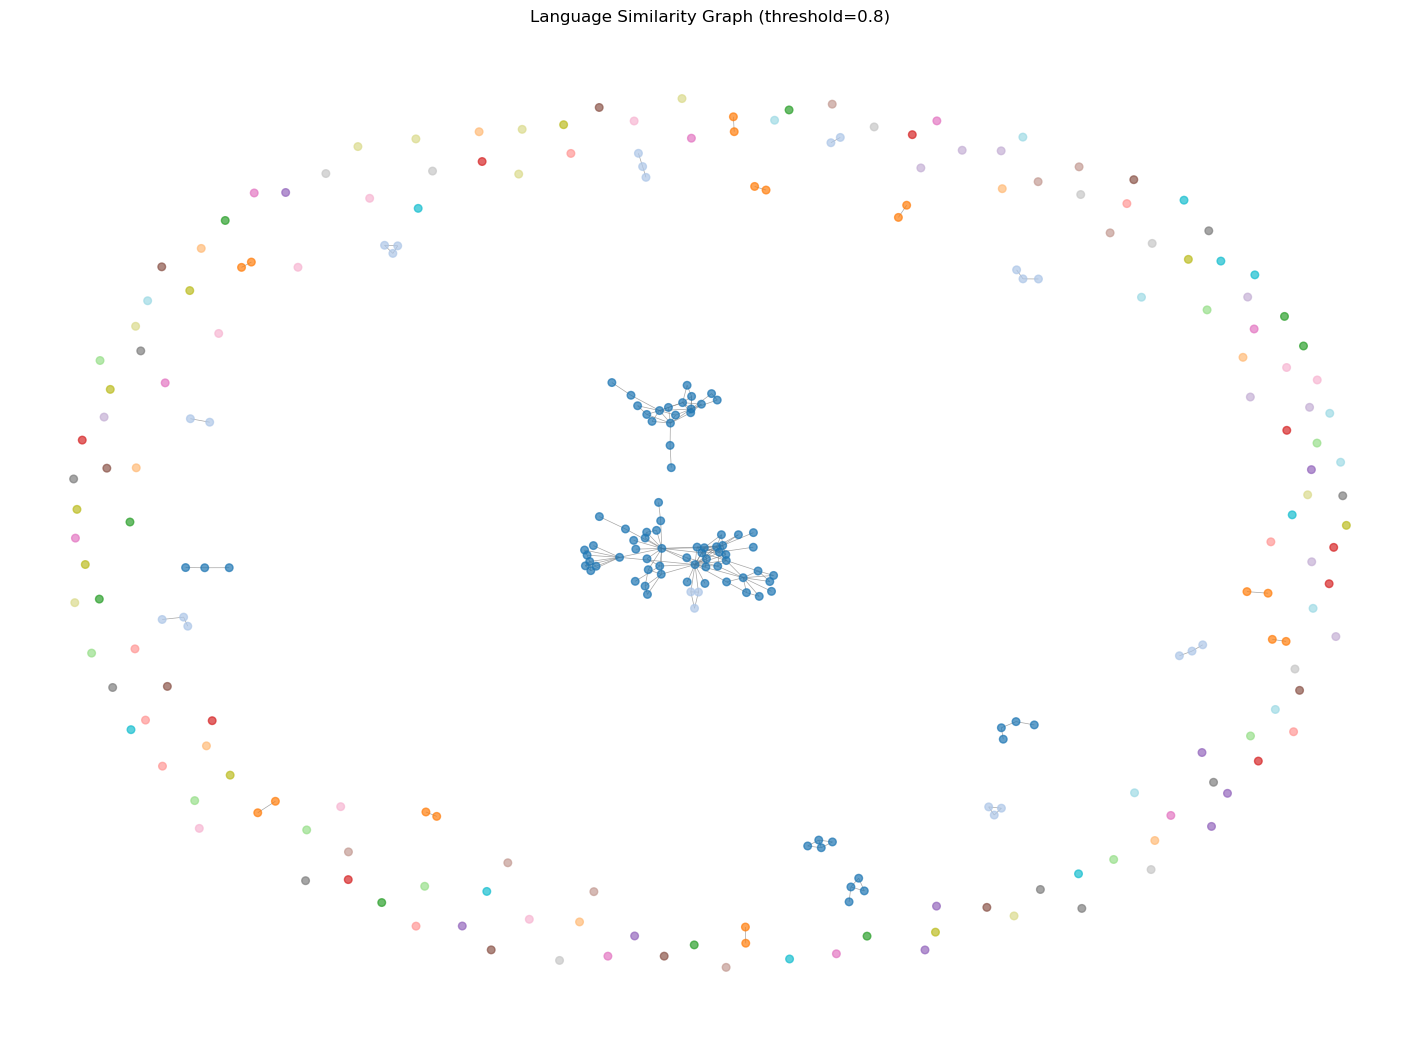


Community 1 (19 languages):
  cic    Chickasaw
  1111   Ñahñú (Otomí)
  mao    Mazateco
  dyo    Diola (Jola-Fogny)
  mfy    Mende
  zam    Zapoteco
  snn    Soninké (Soninkanxaane)
  bci    Baoulé/Baule
  huu    Huitoto Murui
  fum    Peuhl
  mcd    Sharanahua
  btb    Béti
  dinka  Dinka
  ses    Seereer
  chj    Chinanteco, Ajitlán
  qud1   Quichua
  csa    Chinanteco
  lia    Limba
  mxv    Mixteco

Community 2 (19 languages):
  1120   Ido
  moz    Mozarabic (Ajami)
  1119   Interlingua
  cjd    Chamorro
  prv1   Occitan Languedocien
  sco    Scots
  por    Portuguese
  gln    Galician (Galego)
  eng    English
  aub    Asturian (Bable)
  ltn    Latin (Latina)
  cln    Catalan (Català)
  itn    Italian
  frn    French (Français)
  pro    Provençal
  spn    Español (Spanish)
  coi    Corsican
  ltn1   Latin (Latina) 1
  1115   Esperanto

Community 3 (17 languages):
  bem    Bemba
  mlo1   Lunda/Chokwe-lunda
  kde    Makonde
  nel    Ndebele
  lub    Luba-Kasai (Tshiluba)
  sua    S

In [ ]:
# Build graph and find communities
# Threshold 0.8 follows the MSc thesis. Lower values yield smaller, more refined communities.
_, all_communities = build_language_graph_and_find_communities(
    all_distances, threshold=0.8, lang_code_to_node=lang_code_to_node
)
print_communities(all_communities, node_to_lang_code, lang_code_to_name)

### Zooming In: European Languages

We take the European languages that clustered together in the global analysis and
re-run the classification at a tighter threshold to resolve sub-families
(Romance, Germanic, etc.).


Mapped 19 languages to node IDs.
Graph: 19 nodes, 11 edges
Communities found: 10


/tmp/ipykernel_116581/1731843422.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


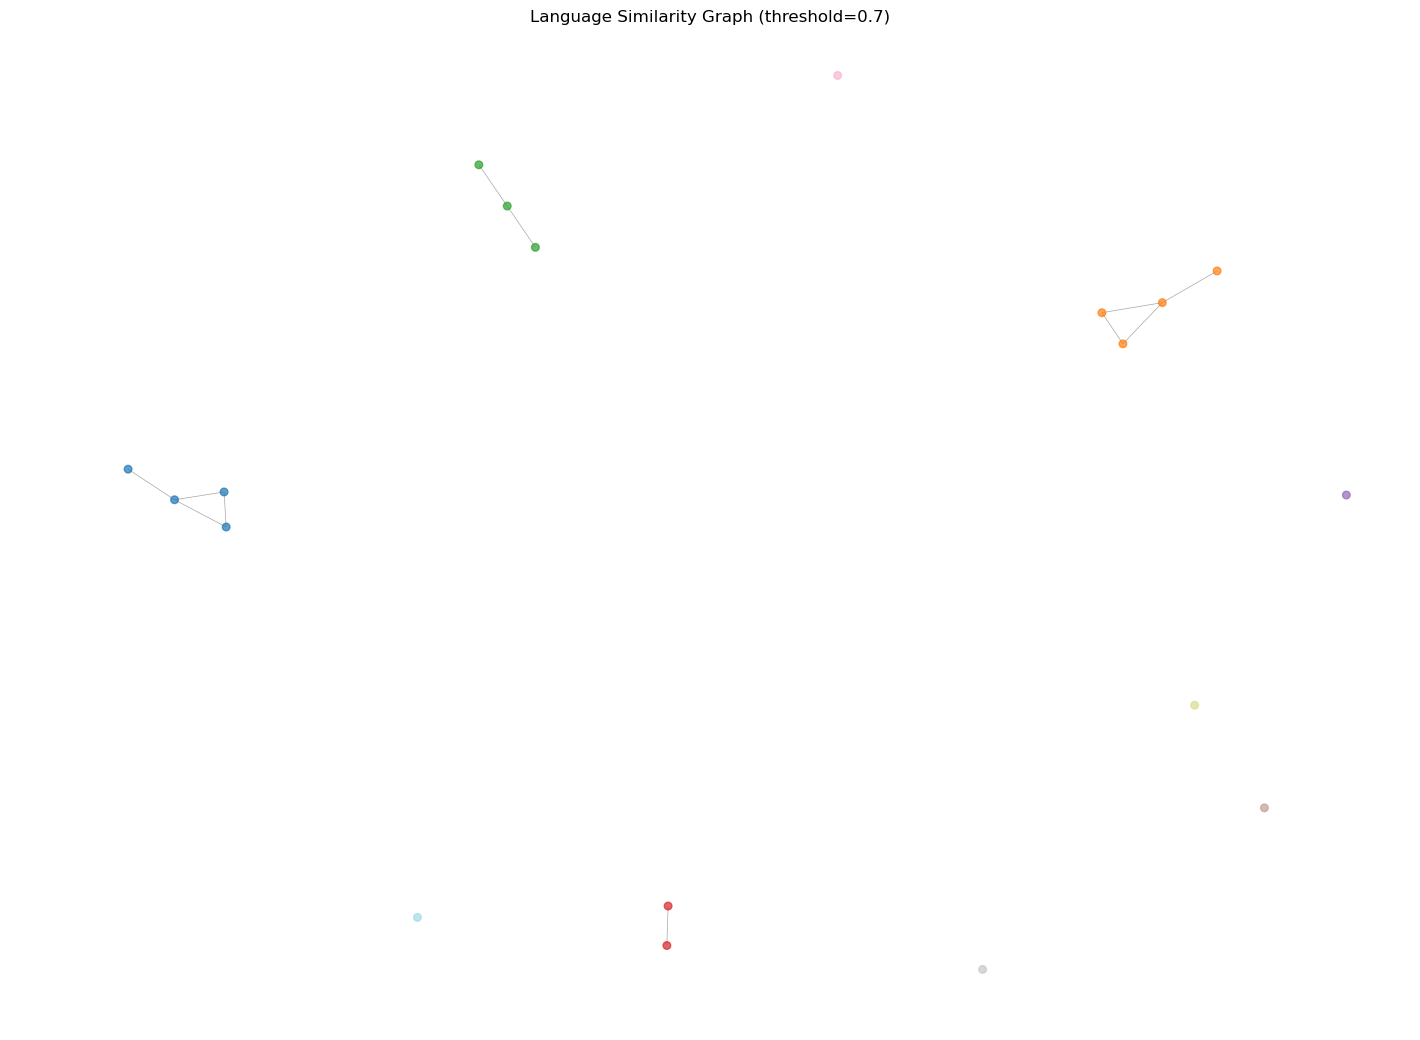


Community 1 (4 languages):
  ltn    Latin (Latina)
  moz    Mozarabic (Ajami)
  ltn1   Latin (Latina) 1
  1119   Interlingua

Community 2 (4 languages):
  por    Portuguese
  aub    Asturian (Bable)
  spn    Español (Spanish)
  gln    Galician (Galego)

Community 3 (3 languages):
  pro    Provençal
  prv1   Occitan Languedocien
  cln    Catalan (Català)

Community 4 (2 languages):
  sco    Scots
  eng    English

Community 5 (1 languages):
  coi    Corsican

Community 6 (1 languages):
  cjd    Chamorro

Community 7 (1 languages):
  itn    Italian

Community 8 (1 languages):
  1115   Esperanto

Community 9 (1 languages):
  1120   Ido

Community 10 (1 languages):
  frn    French (Français)


In [ ]:
european_codes = [
    "pro", "coi", "ltn", "moz", "por", "ltn1", "cjd", "prv1",
    "cln", "sco", "aub", "eng", "itn", "spn", "1115", "1120",
    "1119", "gln", "frn",
]

node_to_lang_code, lang_code_to_node = build_node_mappings(european_codes)
print(f"Mapped {len(lang_code_to_node)} languages to node IDs.")


# Tighter threshold (0.7) to resolve sub-families within the European cluster
european_distances = compute_pairwise_distances(udhr_texts, european_codes)
_, european_communities = build_language_graph_and_find_communities(
    european_distances, threshold=0.7, lang_code_to_node=lang_code_to_node
)
print_communities(european_communities, node_to_lang_code, lang_code_to_name)

### Zooming In: African Languages

Similarly, we zoom into the African language cluster to resolve sub-families.

Mapped 48 languages to node IDs.
Graph: 48 nodes, 27 edges
Communities found: 28


/tmp/ipykernel_116581/1731843422.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


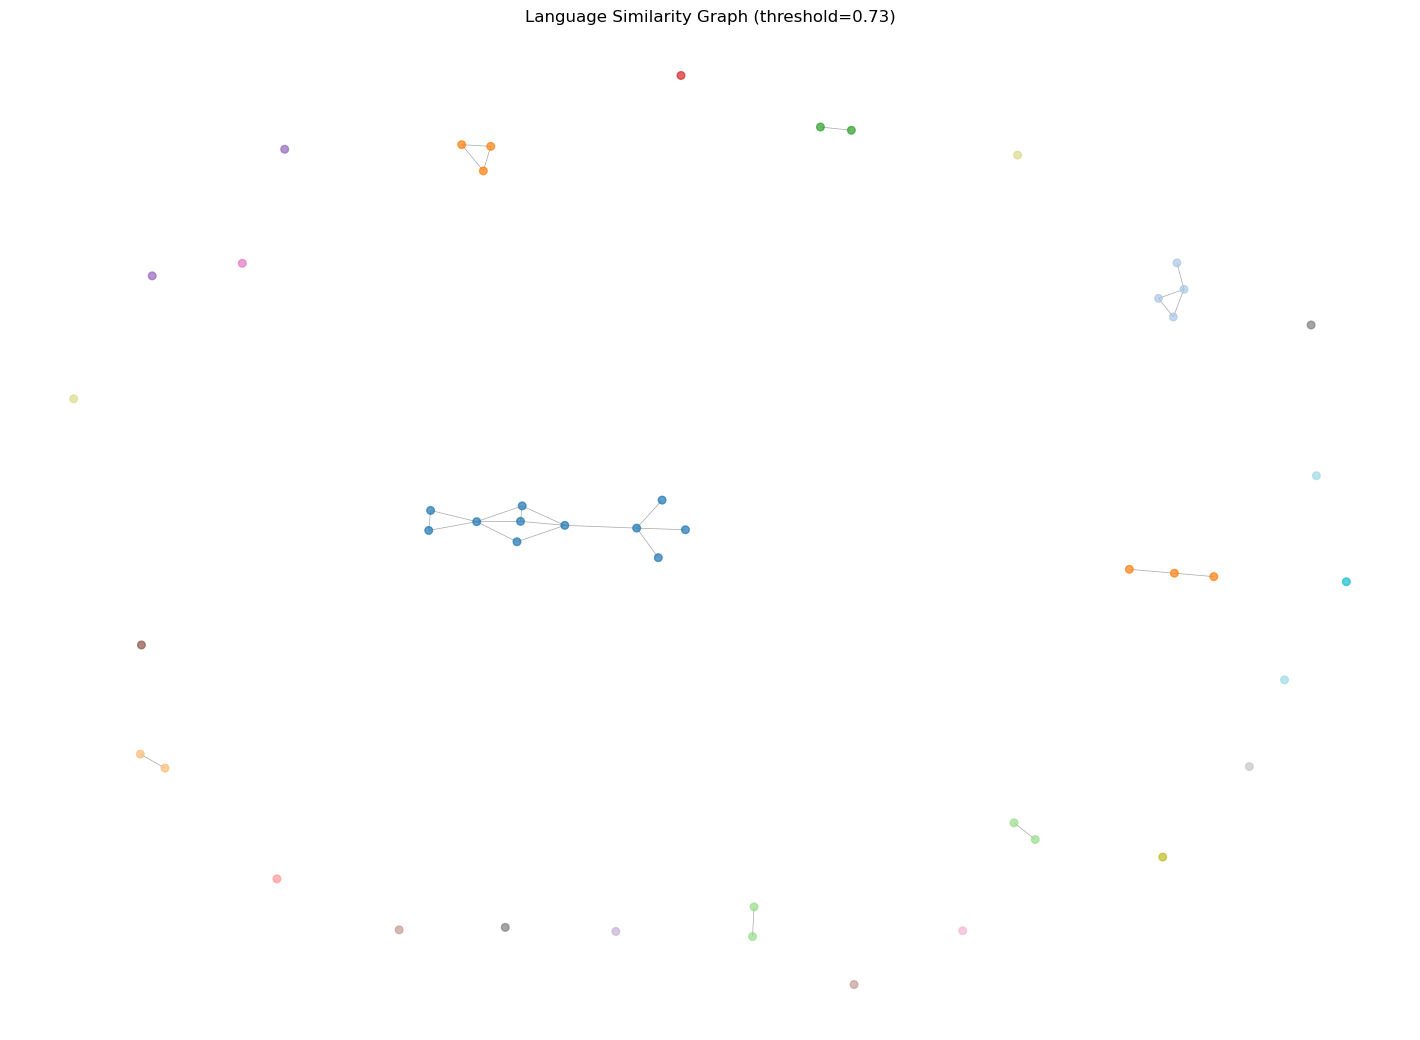


Community 1 (7 languages):
  dyo    Diola (Jola-Fogny)
  cic    Chickasaw
  btb    Béti
  mcd    Sharanahua
  zam    Zapoteco
  chj    Chinanteco, Ajitlán
  mxv    Mixteco

Community 2 (4 languages):
  sua    Sukuma
  nyz    Kinyamwezi (Nyamwezi)
  kqn    Kaonde
  kde    Makonde

Community 3 (4 languages):
  swz1   Siswati
  zuu    Zulu
  xos    Xhosa
  nel    Ndebele

Community 4 (3 languages):
  crs    Seselwa Creole French
  hat    Haitian Creole (Kreyol)
  hat1   Haitian Creole (popular)

Community 5 (3 languages):
  den    Dendi
  ako    Wama
  bba    Batonu (Bariba)

Community 6 (2 languages):
  bra    Bambara
  mni    Maninka

Community 7 (2 languages):
  lia    Limba
  mfy    Mende

Community 8 (2 languages):
  mlo1   Lunda/Chokwe-lunda
  lue    Luvale

Community 9 (2 languages):
  lap1   Luganda/Ganda
  nyn1   Runyankore-rukiga/Nkore-kiga

Community 10 (1 languages):
  agr    Aguaruna

Community 11 (1 languages):
  qud1   Quichua

Community 12 (1 languages):
  huu    Huitoto 

In [ ]:
african_codes = [
    "agr", "swz1", "qud1", "huu", "den", "fum", "zuu", "bra", "lap1",
    "mao", "dyo", "1111", "crs", "hat", "swa", "ako", "lia", "mfy",
    "bci", "sua", "nyz", "cic", "tbz", "mlo1", "gkp1", "ses", "kqn",
    "xos", "btb", "mni", "dag", "yao", "mcd", "hat1", "zam", "bem",
    "csa", "dinka", "nyn1", "lue", "nel", "kde", "chj", "mxv", "kph",
    "bba", "snn", "lub",
]

node_to_lang_code, lang_code_to_node = build_node_mappings(african_codes)
print(f"Mapped {len(lang_code_to_node)} languages to node IDs.")

# Threshold 0.73 chosen to resolve sub-families within the African cluster
african_distances = compute_pairwise_distances(udhr_texts, african_codes)
_, african_communities = build_language_graph_and_find_communities(
    african_distances, threshold=0.73, lang_code_to_node=lang_code_to_node
)
print_communities(african_communities, node_to_lang_code, lang_code_to_name)

### Export Communities for LaTeX


In [ ]:
def format_communities_for_latex(
    communities: list[set[int]],
    node_to_lang_code: dict[int, str],
    lang_code_to_name: dict[str, str],
) -> str:
    """Format detected communities as semicolon-separated lines for LaTeX inclusion.

    Parameters
    ----------
    communities : list[set[int]]
        Communities as sets of node IDs.
    node_to_lang_code : dict[int, str]
        Mapping from node ID to language code.
    lang_code_to_name : dict[str, str]
        Mapping from language code to name.

    Returns
    -------
    str
        Formatted text suitable for pasting into a LaTeX document.
    """
    lines = []
    for i, comm in enumerate(communities, start=1):
        names = [lang_code_to_name.get(node_to_lang_code[n], "?") for n in sorted(comm)]
        lines.append(f"{i} : {' ; '.join(names)}")
    return "\n".join(lines)


node_to_lang_code, lang_code_to_node = build_node_mappings(list(udhr_texts.keys()))
print(f"Mapped {len(lang_code_to_node)} languages to node IDs.")

print(format_communities_for_latex(all_communities, node_to_lang_code, lang_code_to_name))

Mapped 278 languages to node IDs.
1 : Chickasaw ; Ñahñú (Otomí) ; Mazateco ; Diola (Jola-Fogny) ; Mende ; Zapoteco ; Soninké (Soninkanxaane) ; Baoulé/Baule ; Huitoto Murui ; Peuhl ; Sharanahua ; Béti ; Dinka ; Seereer ; Chinanteco, Ajitlán ; Quichua ; Chinanteco ; Limba ; Mixteco
2 : Ido ; Mozarabic (Ajami) ; Interlingua ; Chamorro ; Occitan Languedocien ; Scots ; Portuguese ; Galician (Galego) ; English ; Asturian (Bable) ; Latin (Latina) ; Catalan (Català) ; Italian ; French (Français) ; Provençal ; Español (Spanish) ; Corsican ; Latin (Latina) 1 ; Esperanto
3 : Bemba ; Lunda/Chokwe-lunda ; Makonde ; Ndebele ; Luba-Kasai (Tshiluba) ; Sukuma ; Luvale ; Siswati ; Zulu ; Yao ; Kaonde ; Swahili/Kiswahili ; Xhosa ; Kanuri Yerwa ; Kinyamwezi (Nyamwezi) ; Runyankore-rukiga/Nkore-kiga ; Luganda/Ganda
4 : Wama ; Kpelewo ; Maninka ; Batonu (Bariba) ; Dendi ; Ditammari ; Dagbani ; Bambara
5 : Bahasa Indonesia ; Madurese ; Achehnese ; Sundanese ; Bugisnese ; Bahasa Melayu (Malay) ; Javanese ; Mi

## Future Directions

Some ideas for extending this work:

- **Character filtering:** Would removing punctuation or special characters improve results?
- **Optimal snippet length:** Systematic search for the best snippet length `b` for
  both identification and classification tasks.
- **Human validation:** Present humans with three texts and ask them to identify the odd
  one out, then compare their judgments with the compression-based distances.
- **Alternative compressors:** Test with bzip2, zstd, or other algorithms to see how the
  choice of compressor affects accuracy.
- **Pulaar vs. Peuhl:** Investigate the identical UDHR texts by examining the original PDFs.
- **Symbol distribution baseline:** Compare single-character frequency distributions as a simpler alternative to compression-based distances.
- **Audio-based identification:** Use audio recordings instead of text to avoid the bias introduced by the choice of writing script.
- **Broader datasets:** The Kaggle corpus appears to be topically narrow. Search for more diverse multilingual corpora.
- **Language tree:** Community detection might not be neccessary. The threshold can be varied slowly so that the graph gets progressively connected, almost forming a tree structure.